# Global Sea Ice data

In this tutorial, we will look at how to access and analyse the following global datasets:

ADD DESCRIPTION OF EACH AND MAKE LINK TO EACH SUBSECTION

- **Sea ice concentration**: 
- **Sea ice drift**
- **Mapping the edge of the sea ice**
- **Sea ice type**
- **Sea ice emissivity**
- **Sea ice extent**

EACH OF THE DATASETS ARE CREATED MADE AVAILABLE BY THE OSI-SAF PROJECT (ABOUT). 



https://thredds.met.no/thredds/osisaf/osisaf.html

https://thredds.met.no/thredds/osisaf/osisaf_seaiceconc.html

2005-onwards: SSMIS
Dataset information: https://osi-saf.eumetsat.int/products/osi-401-d
THREDDS catalogue: https://thredds.met.no/thredds/catalog/osisaf/met.no/ice/conc/catalog.html

2016-onwards: 
Dataset information: https://osi-saf.eumetsat.int/products/osi-408-a
THREDDS catalogue: https://thredds.met.no/thredds/catalog/osisaf/met.no/ice/amsr2_conc/catalog.html

Use this as my guide
https://github.com/TomLav/snippets/blob/main/Read%20OSISAF%20CCI%20Sea%20Ice%20Concentration%20CDR.ipynb

## Preparing our Python session

Before we begin accessing the data, let's first import the modules that we will use

In [2]:
from siphon.catalog import TDSCatalog # For looping through the THREDDs catalogue
import xarray as xr
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

In [1]:
catalog_url = 'https://thredds.met.no/thredds/osisaf/osisaf.xml'

Loading in one file

In [2]:
ds = xr.open_dataset('https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/amsr2_conc/2025/02/ice_conc_nh_polstere-100_amsr2_202502011200.nc')
ds

<xarray.Dataset> Size: 27MB
Dimensions:                   (time: 1, nv: 2, xc: 760, yc: 1120)
Coordinates:
  * time                      (time) datetime64[ns] 8B 2025-02-01T12:00:00
  * xc                        (xc) float64 6kB -3.845e+03 ... 3.745e+03
  * yc                        (yc) float64 9kB 5.845e+03 ... -5.345e+03
    lat                       (yc, xc) float32 3MB ...
    lon                       (yc, xc) float32 3MB ...
Dimensions without coordinates: nv
Data variables:
    Polar_Stereographic_Grid  int32 4B ...
    time_bnds                 (time, nv) datetime64[ns] 16B ...
    ice_conc                  (time, yc, xc) float32 3MB ...
    raw_ice_conc_values       (time, yc, xc) float32 3MB ...
    status_flag               (time, yc, xc) float32 3MB ...
    total_uncertainty         (time, yc, xc) float32 3MB ...
    smearing_uncertainty      (time, yc, xc) float32 3MB ...
    algorithm_uncertainty     (time, yc, xc) float32 3MB ...
Attributes: (12/30)
    title:                   Level-3 Sea Ice Concentration Analysis (AMSR2) f...
    product_id:              OSI-408-a
    instrument_type:         AMSR2
    platform_name:           GCOM-W
    easternmost_longitude:   180.0
    westernmost_longitude:   -180.0
    ...                      ...
    references:              Product User Manual and Algorithm Theoretical Ba...
    history:                 Created 2025-02-02 02:00:59
    product_version:         4.1
    software_version:        2.0.4
    netcdf_version:          1.5.4
    Conventions:             CF-1.6

Loading in data from a date and hemisphere of our choosing

In [13]:
desired_date = '20240201'  # YYYYMMDD
desired_hemisphere = 'n' # "n" for northern or "s" for southern

date_obj = datetime.strptime(desired_date, "%Y%m%d")
year = date_obj.year
month = f"{date_obj.month:02d}"

url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/amsr2_conc/{year}/{month}/ice_conc_{desired_hemisphere}h_polstere-100_amsr2_{desired_date}1200.nc'
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 27MB
Dimensions:                   (time: 1, nv: 2, xc: 760, yc: 1120)
Coordinates:
  * time                      (time) datetime64[ns] 8B 2024-02-01T12:00:00
  * xc                        (xc) float64 6kB -3.845e+03 ... 3.745e+03
  * yc                        (yc) float64 9kB 5.845e+03 ... -5.345e+03
    lat                       (yc, xc) float32 3MB ...
    lon                       (yc, xc) float32 3MB ...
Dimensions without coordinates: nv
Data variables:
    Polar_Stereographic_Grid  int32 4B ...
    time_bnds                 (time, nv) datetime64[ns] 16B ...
    ice_conc                  (time, yc, xc) float32 3MB ...
    raw_ice_conc_values       (time, yc, xc) float32 3MB ...
    status_flag               (time, yc, xc) float32 3MB ...
    total_uncertainty         (time, yc, xc) float32 3MB ...
    smearing_uncertainty      (time, yc, xc) float32 3MB ...
    algorithm_uncertainty     (time, yc, xc) float32 3MB ...
Attributes: (12/30)
    title:                   Level-3 Sea Ice Concentration Analysis (AMSR2) f...
    product_id:              OSI-408-a
    instrument_type:         AMSR2
    platform_name:           GCOM-W
    easternmost_longitude:   180.0
    westernmost_longitude:   -180.0
    ...                      ...
    references:              Product User Manual and Algorithm Theoretical Ba...
    history:                 Created 2024-02-02 02:00:59
    product_version:         4.1
    software_version:        2.0.4
    netcdf_version:          1.5.4
    Conventions:             CF-1.6

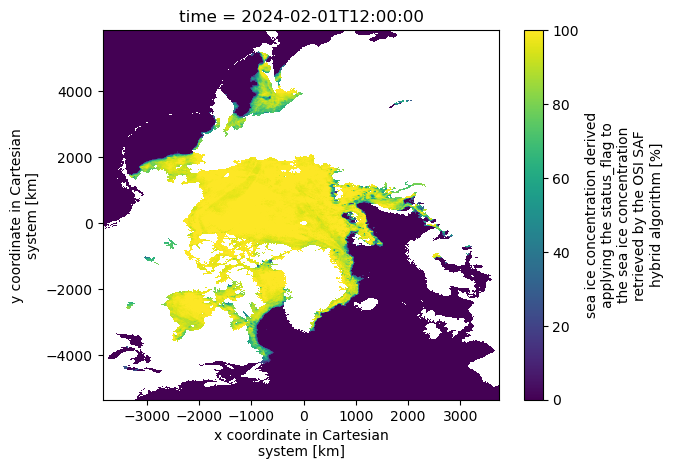

In [5]:
ds['ice_conc'].plot()
plt.show()

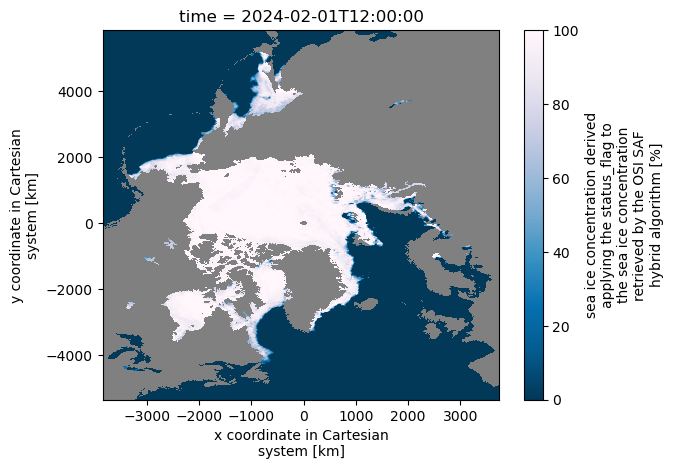

In [6]:
cmap = cm.PuBu_r
cmap = cmap.with_extremes(bad='grey') # Setting colour where there is no values (e.g. land)
ds['ice_conc'].plot(cmap=cmap)
plt.show()

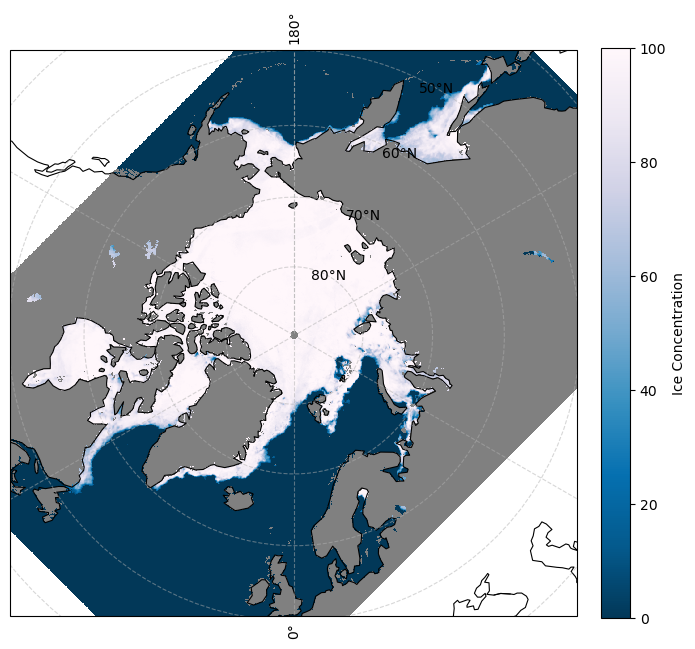

In [14]:
# Define projection
proj = ccrs.NorthPolarStereo()
transform = ccrs.PlateCarree()

# Create figure and axis with the projection
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))

# Set extent to include only the Northern Hemisphere above 60°N
ax.set_extent([-180, 180, 50, 90], crs=transform)

cmap = cm.PuBu_r
cmap = cmap.with_extremes(bad='grey') # Setting colour where there is no values (e.g. land)

pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ice_conc'].isel(time=0),
                     cmap=cmap, transform=transform)

# Add coastlines and gridlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Ice Concentration")

plt.show()

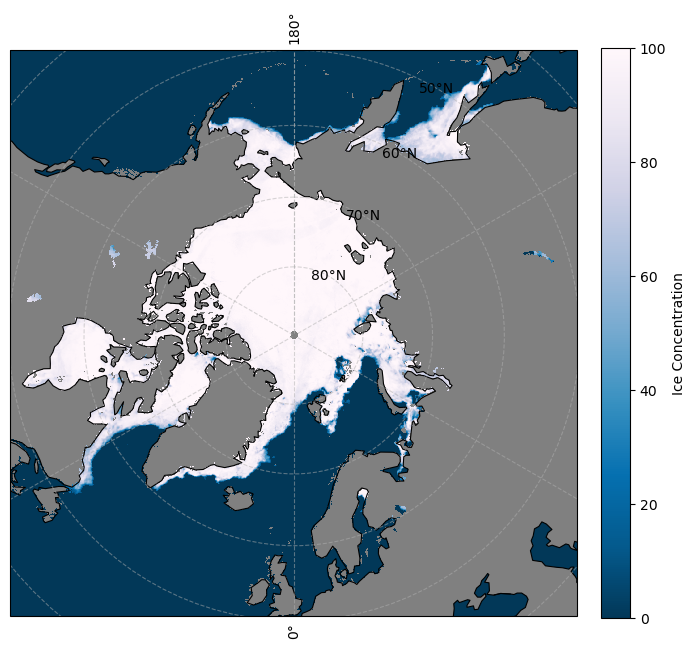

In [22]:
# Define projection
proj = ccrs.NorthPolarStereo()
transform = ccrs.PlateCarree()

# Create figure and axis with the projection
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))

# Set extent to include only the Northern Hemisphere above 50°N
ax.set_extent([-180, 180, 50, 90], crs=transform)

cmap = cm.PuBu_r
cmap = cmap.with_extremes(bad='grey') # Setting colour where there is no values (e.g. land)

pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ice_conc'].isel(time=0),
                     cmap=cmap, transform=transform)

# Add coastlines and gridlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

# Get the colour for ice concentration = 0
ocean_color = cmap(0)
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor=ocean_color)
ax.add_feature(cfeature.LAND, zorder=0, facecolor='grey')

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Ice Concentration")

plt.show()

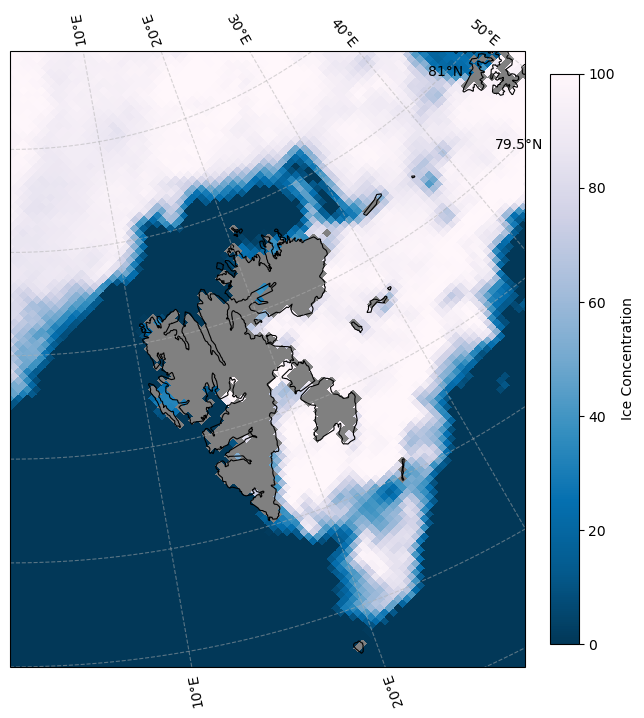

In [23]:
# Define projection
proj = ccrs.NorthPolarStereo()
transform = ccrs.PlateCarree()

# Create figure and axis with the projection
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))

# Set extent to include only area around Svalbard
ax.set_extent([0, 30, 75, 83], crs=transform)

cmap = cm.PuBu_r
cmap = cmap.with_extremes(bad='grey') # Setting colour where there is no values (e.g. land)

pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ice_conc'].isel(time=0),
                     cmap=cmap, transform=transform)

# Add coastlines and gridlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Ice Concentration")

plt.show()

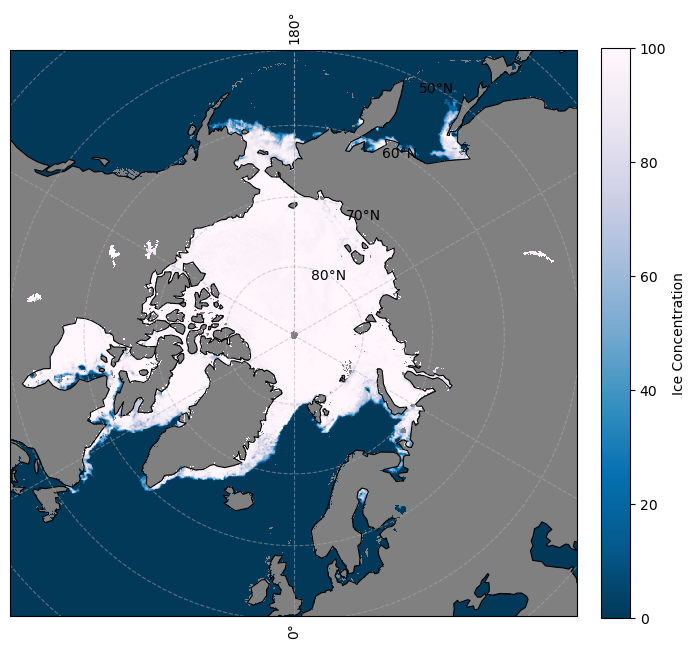

In [22]:
def plot_ice_conc_one_day(year, month, day):
    url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/amsr2_conc/{year}/{month}/ice_conc_nh_polstere-100_amsr2_{year}{month}{day}1200.nc'

    ds = xr.open_dataset(url)

    proj = ccrs.NorthPolarStereo()
    transform = ccrs.PlateCarree()
    
    fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))
    
    ax.set_extent([-180, 180, 50, 90], crs=transform)
    
    cmap = cm.PuBu_r
    cmap = cmap.with_extremes(bad='grey') # Setting colour where there is no values (e.g. land)
    
    pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ice_conc'].isel(time=0),
                         cmap=cmap, transform=transform)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

    # Get the colour for ice concentration = 0
    ocean_color = cmap(0)
    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor=ocean_color)
    ax.add_feature(cfeature.LAND, zorder=0, facecolor='grey')

    cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Ice Concentration")

    plt.show()
    
year = '2024'
month = '04'
day = '15'

plot_ice_conc_one_day(year,month,day)


## Sea ice drift

In [49]:
url = 'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/drift_lr/merged/2025/03/ice_drift_nh_polstere-625_multi-oi_202502281200-202503021200.nc'
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 950kB
Dimensions:                   (time: 1, nv: 2, xc: 119, yc: 177)
Coordinates:
  * time                      (time) datetime64[ns] 8B 2025-03-02T12:00:00
  * xc                        (xc) float64 952B -3.75e+03 ... 3.625e+03
  * yc                        (yc) float64 1kB 5.75e+03 5.688e+03 ... -5.25e+03
    lat                       (yc, xc) float32 84kB ...
    lon                       (yc, xc) float32 84kB ...
Dimensions without coordinates: nv
Data variables:
    Polar_Stereographic_Grid  int32 4B ...
    time_bnds                 (time, nv) datetime64[ns] 16B ...
    dt0                       (time, yc, xc) timedelta64[ns] 169kB ...
    lon1                      (time, yc, xc) float32 84kB ...
    lat1                      (time, yc, xc) float32 84kB ...
    dt1                       (time, yc, xc) timedelta64[ns] 169kB ...
    dX                        (time, yc, xc) float32 84kB ...
    dY                        (time, yc, xc) float32 84kB ...
    status_flag               (time, yc, xc) int8 21kB ...
    uncert_dX_and_dY          (time, yc, xc) float32 84kB ...
Attributes: (12/33)
    title:                   Daily Low Resolution Sea Ice Displacement from O...
    product_id:              OSI-405
    product_name:            osi_saf_lr_ice_drift
    product_status:          operational
    abstract:                Gridded ice displacement fields obtained from sa...
    topiccategory:           Oceans ClimatologyMeteorologyAtmosphere
    ...                      ...
    software_version:        5.1
    netcdf_version:          4.7.4
    Conventions:             CF-1.7
    id:                      OSI-405-c
    processing_level:        Level-3 (l3)
    date_created:            2025-03-03 04:32:05.857060

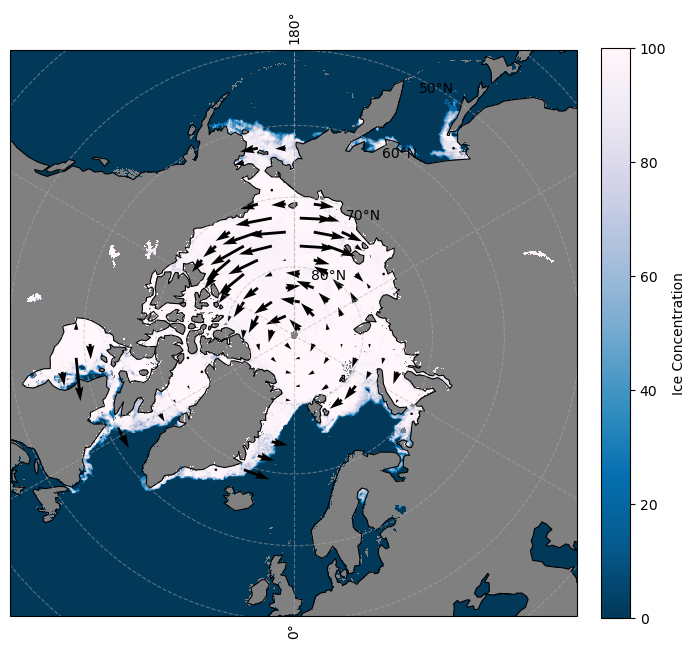

In [8]:
def plot_ice_drift_one_day(year, month, day):
    # Load in ice concentration data
    ice_conc_url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/amsr2_conc/{year}/{month}/ice_conc_nh_polstere-100_amsr2_{year}{month}{day}1200.nc'
    ds1 = xr.open_dataset(ice_conc_url)

    # Load in ice drift data
    # Convert input to datetime and subtract one day
    date = datetime(int(year), int(month), int(day))
    date_start = date - timedelta(days=2)

    year_start, month_start, day_start = date_start.strftime("%Y"), date_start.strftime("%m"), date_start.strftime("%d")
    ice_drift_url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/drift_lr/merged/{year}/{month}/ice_drift_nh_polstere-625_multi-oi_{year_start}{month_start}{day_start}1200-{year}{month}{day}1200.nc'
    ds2 = xr.open_dataset(ice_drift_url)
    
    proj = ccrs.NorthPolarStereo()
    transform = ccrs.PlateCarree()
    
    fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))
    
    ax.set_extent([-180, 180, 50, 90], crs=transform)
    
    cmap = cm.PuBu_r
    cmap = cmap.with_extremes(bad='grey') # Setting colour where there is no values (e.g. land)
    
    pcm = ax.pcolormesh(ds1['lon'], ds1['lat'], ds1['ice_conc'].isel(time=0),
                         cmap=cmap, transform=transform)

    f = 5
    lon = ds2['lon'].values[::f, ::f]
    lat = ds2['lat'].values[::f, ::f]
    # TODO: dX and dY are not adjusted to the geospatial grid.
    # TODO: Consider plotting on a logarithmic scale as some quivers are really long and some too short
    dX = ds2['dX'].isel(time=0).values[::f, ::f]
    dY = ds2['dY'].isel(time=0).values[::f, ::f]

    dX_trans, dY_trans = transform.transform_vectors(proj, lon, lat, dX, dY)
    
    ax.quiver(lon, lat, dX_trans, dY_trans,
          transform=transform, angles="xy", scale_units="xy", scale=7e-5, width=0.005)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

    # Get the colour for ice concentration = 0
    ocean_color = cmap(0)
    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor=ocean_color)
    ax.add_feature(cfeature.LAND, zorder=0, facecolor='grey')

    cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Ice Concentration")

    plt.show()
    
year = '2024'
month = '04'
day = '15'

plot_ice_drift_one_day(year,month,day)


## Sea ice edge

In [23]:
url = 'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/edge/2025/03/ice_edge_nh_polstere-100_multi_202503021200.nc'
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 31MB
Dimensions:                   (time: 1, nv: 2, xc: 760, yc: 1120)
Coordinates:
  * time                      (time) datetime64[ns] 8B 2025-03-02T12:00:00
  * xc                        (xc) float64 6kB -3.84e+03 -3.83e+03 ... 3.74e+03
  * yc                        (yc) float64 9kB 5.84e+03 5.83e+03 ... -5.34e+03
    lat                       (yc, xc) float32 3MB ...
    lon                       (yc, xc) float32 3MB ...
Dimensions without coordinates: nv
Data variables:
    Polar_Stereographic_Grid  int32 4B ...
    time_bnds                 (time, nv) datetime64[ns] 16B ...
    ice_edge                  (time, yc, xc) float32 3MB ...
    status_flag               (time, yc, xc) float32 3MB ...
    uncertainty               (time, yc, xc) float32 3MB ...
    param_used                (time, yc, xc) float32 3MB ...
    orbit_num_ascat           (time, yc, xc) float32 3MB ...
    orbit_num_amsr            (time, yc, xc) float32 3MB ...
    orbit_num_ssmis           (time, yc, xc) float32 3MB ...
Attributes: (12/33)
    title:                  Daily Sea Ice Edge Analysis from OSI SAF EUMETSAT
    id:                     OSI-402-d
    product_id:             OSI-402-d
    product_name:           osi_saf_ice_edge
    product_status:         operational
    processing_level:       Level-3 (l3)
    ...                     ...
    history:                2025-03-03 creation
    product_version:        5.0
    software_version:       5.3
    netcdf_version:         4.7.4
    Conventions:            CF-1.7
    date_created:           2025-03-03 04:24:00.396655

The data are derived from the sea ice concentration data. Sea ice edge differs between the classes open water (value = 1), open ice (value = 2), and closed ice (value = 3) which are defined from the ice concentration thresholds of 30 % and 70 %, respectively. 

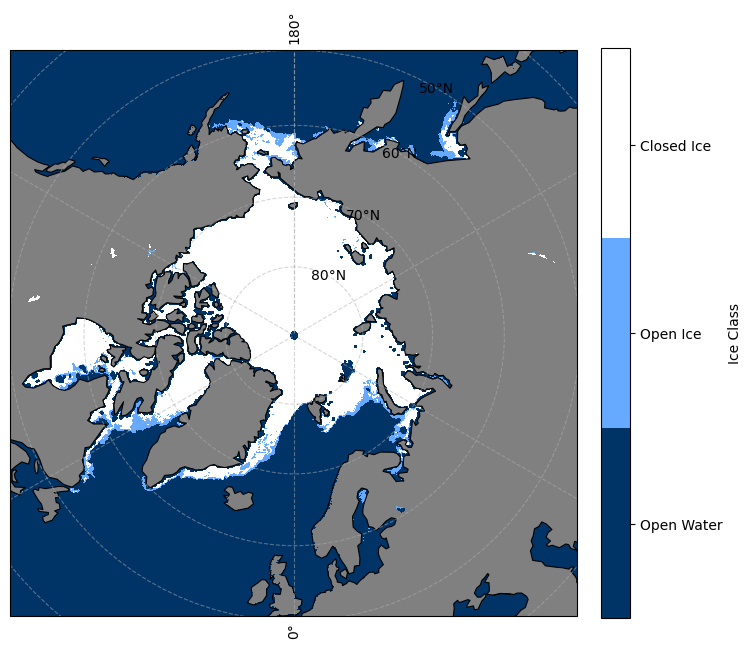

In [36]:
def plot_ice_edge_one_day(year, month, day):
    url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/edge/{year}/{month}/ice_edge_nh_polstere-100_multi_{year}{month}{day}1200.nc'

    ds = xr.open_dataset(url)

    proj = ccrs.NorthPolarStereo()
    transform = ccrs.PlateCarree()
    
    fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))
    
    ax.set_extent([-180, 180, 50, 90], crs=transform)
    
    cmap = ListedColormap(['#003366', '#66aaff', '#ffffff'])
    
    pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ice_edge'].isel(time=0),
                         cmap=cmap, transform=transform)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

    # Get the colour for ice concentration = 0
    ocean_color = cmap(0)
    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor=ocean_color)
    ax.add_feature(cfeature.LAND, zorder=0, facecolor='grey')

    cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Ice Class")

    # Set custom ticks and labels
    cbar.set_ticks([1.33, 2, 2.66])  # Position of the ticks in the colorbar
    cbar.set_ticklabels(['Open Water', 'Open Ice', 'Closed Ice'])  # Custom labels

    plt.show()
    
year = '2024'
month = '04'
day = '15'

plot_ice_edge_one_day(year,month,day)
#TODO: Use legend instead of colorbar.

## Ice type

In [37]:
url = 'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/type/2025/03/ice_type_nh_polstere-100_multi_202503021200.nc'
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 31MB
Dimensions:                   (time: 1, nv: 2, xc: 760, yc: 1120)
Coordinates:
  * time                      (time) datetime64[ns] 8B 2025-03-02T12:00:00
  * xc                        (xc) float64 6kB -3.84e+03 -3.83e+03 ... 3.74e+03
  * yc                        (yc) float64 9kB 5.84e+03 5.83e+03 ... -5.34e+03
    lat                       (yc, xc) float32 3MB ...
    lon                       (yc, xc) float32 3MB ...
Dimensions without coordinates: nv
Data variables:
    Polar_Stereographic_Grid  int32 4B ...
    time_bnds                 (time, nv) datetime64[ns] 16B ...
    ice_type                  (time, yc, xc) float32 3MB ...
    status_flag               (time, yc, xc) float32 3MB ...
    uncertainty               (time, yc, xc) float32 3MB ...
    param_used                (time, yc, xc) float32 3MB ...
    orbit_num_ascat           (time, yc, xc) float32 3MB ...
    orbit_num_amsr            (time, yc, xc) float32 3MB ...
    orbit_num_ssmis           (time, yc, xc) float32 3MB ...
Attributes: (12/33)
    title:                  Daily Sea Ice Type Analysis from OSI SAF EUMETSAT
    id:                     OSI-403-d
    product_id:             OSI-403-d
    product_name:           osi_saf_ice_type
    product_status:         operational
    processing_level:       Level-3 (l3)
    ...                     ...
    history:                2025-03-03 creation
    product_version:        5.0
    software_version:       5.3
    netcdf_version:         4.7.4
    Conventions:            CF-1.7
    date_created:           2025-03-03 04:24:07.889572

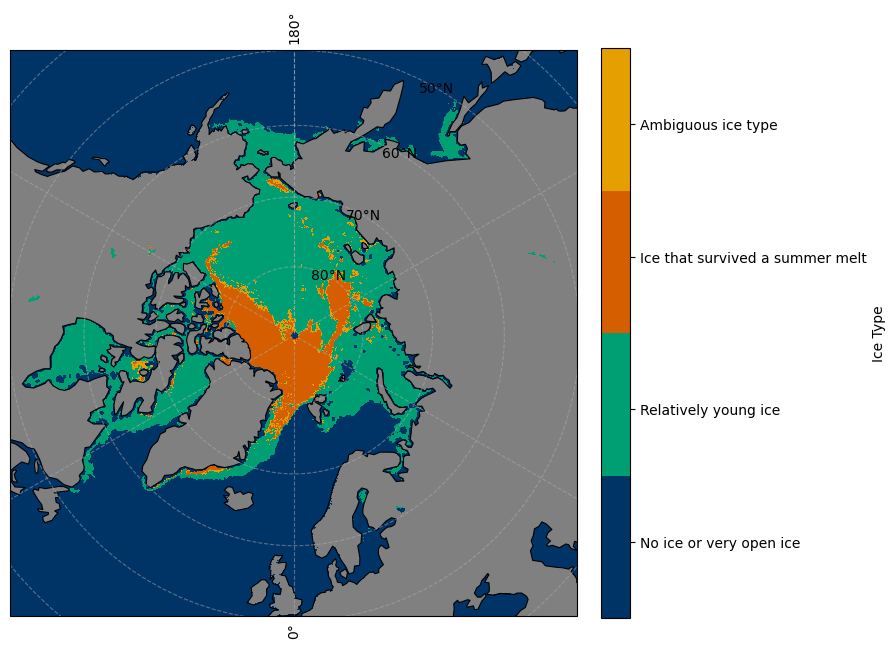

In [6]:
def plot_ice_type_one_day(year, month, day):
    url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/type/{year}/{month}/ice_type_nh_polstere-100_multi_{year}{month}{day}1200.nc'

    ds = xr.open_dataset(url)

    proj = ccrs.NorthPolarStereo()
    transform = ccrs.PlateCarree()
    
    fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))
    
    ax.set_extent([-180, 180, 50, 90], crs=transform)
    
    cmap = ListedColormap(['#003366', '#009E73', '#D55E00', '#E69F00'])
    
    pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ice_type'].isel(time=0),
                         cmap=cmap, transform=transform)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

    # Get the colour for ice concentration = 0
    ocean_color = cmap(0)
    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor=ocean_color)
    ax.add_feature(cfeature.LAND, zorder=0, facecolor='grey')

    cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Ice Type")

    # Set custom ticks and labels
    cbar.set_ticks([1.4,2.1,2.9,3.6])  # Position of the ticks in the colorbar
    cbar.set_ticklabels(['No ice or very open ice', 'Relatively young ice', 'Ice that survived a summer melt', 'Ambiguous ice type'])  # Custom labels

    plt.show()
    
year = '2024'
month = '04'
day = '15'

plot_ice_type_one_day(year,month,day)

# TODO: Use key instead of colour bar
# TODO: Make animation of this too

MAKE THIS A LEGEND (KEY) INSTEAD OF COLOUR BAR.

ASK THOMAS ABOUT WHETHER THESE CATEGORIES ARE RELIABLE. 

ANIMATION: ICE CONCENTRATION WITH QUIVERS (LEFT) ICE TYPE (RIGHT) EXTENT (BOTTOM)

## Sea ice emissivity

In [46]:
url = 'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/emis/2025/03/ice_emis_nh_stere-100_ssmis_202503021200.nc'
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 31MB
Dimensions:                   (xc: 760, yc: 1120)
Coordinates:
  * xc                        (xc) float64 6kB -3.845e+06 ... 3.735e+06
  * yc                        (yc) float64 9kB 5.835e+06 ... -5.345e+06
    lon                       (yc, xc) float32 3MB ...
    lat                       (yc, xc) float32 3MB ...
Data variables:
    Polar_Stereographic_Grid  int32 4B ...
    flag                      (yc, xc) float32 3MB ...
    R                         (yc, xc) float32 3MB ...
    S                         (yc, xc) float32 3MB ...
    ev                        (yc, xc) float32 3MB ...
    e                         (yc, xc) float32 3MB ...
    u                         (yc, xc) float32 3MB ...
    teff                      (yc, xc) float32 3MB ...
Attributes: (12/30)
    title:                   The near 50GHz sea ice emissivity
    institution:             The EUMETSAT Ocean and Sea Ice Satellite Applica...
    product_id:              OSI-404
    product_name:            osi_saf_ice_emis
    product_status:          operational
    abstract:                The sea ice surface emissivity is representative...
    ...                      ...
    references:              http://osisaf.met.no\n http://www.osi-saf.org
    history:                 2025-03-03 creation
    product_version:         1.4
    software_version:        5.0.1
    netcdf_version:          3.6.3
    Conventions:             CF-1.5

No time dimension, different to all others.

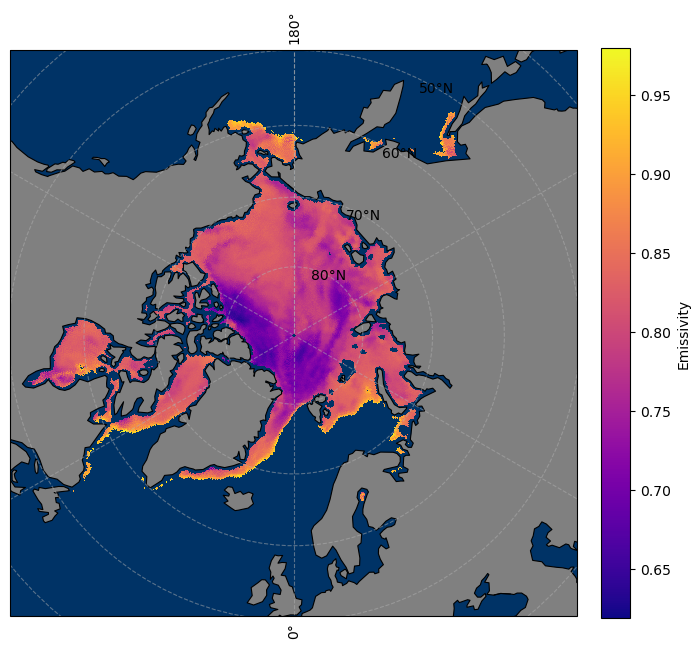

In [54]:
def plot_ice_emissivity_one_day(year, month, day):
    url = f'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/emis/{year}/{month}/ice_emis_nh_stere-100_ssmis_{year}{month}{day}1200.nc'

    ds = xr.open_dataset(url)

    proj = ccrs.NorthPolarStereo()
    transform = ccrs.PlateCarree()
    
    fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8, 8))
    
    ax.set_extent([-180, 180, 50, 90], crs=transform)
    
    cmap = cm.plasma
    
    pcm = ax.pcolormesh(ds['lon'], ds['lat'], ds['ev'],
                         cmap=cmap, transform=transform)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#003366')
    ax.add_feature(cfeature.LAND, zorder=0, facecolor='grey')

    cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Emissivity")

    plt.show()
    
year = '2024'
month = '04'
day = '15'

plot_ice_emissivity_one_day(year,month,day)

## Sea ice extent

In [55]:
url = 'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/index/v2p2/nh/osisaf_nh_sie_daily.nc'
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 406kB
Dimensions:        (time: 16932, nv: 2)
Coordinates:
  * time           (time) datetime64[ns] 135kB 1978-10-25 ... 2025-03-03
    sic_threshold  float32 4B ...
    lat            float32 4B ...
    lon            float32 4B ...
Dimensions without coordinates: nv
Data variables:
    lat_bounds     (nv) float32 8B ...
    lon_bounds     (nv) float32 8B ...
    area           |S64 64B ...
    sie            (time) float64 135kB ...
    source         (time) float64 135kB ...
Attributes: (12/35)
    title:                   Daily Northern Hemisphere Sea Ice Extent from EU...
    product_id:              OSI-420
    product_name:            OSI SAF Sea Ice Index
    product_status:          demonstration
    version:                 v2p2
    summary:                 Time series of Daily Sea Ice Extent (SIE) for No...
    ...                      ...
    distribution_statement:  Free
    copyright_statement:     Copyright 2025 EUMETSAT
    references:              Product User Manual for OSI-420, Lavergne et al....
    featureType:             timeSeries
    DODS.strlen:             2
    DODS.dimName:            nchar

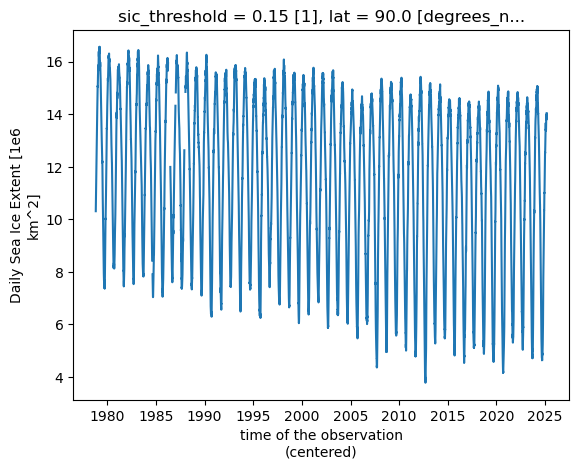

In [56]:
ds['sie'].plot()
plt.show()